<a href="https://colab.research.google.com/github/muhammadalihussnain/IBM-PROJECTS/blob/main/frist_quantum_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install 'qiskit[visualization]' qiskit-ibm-runtime qiskit-aer
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService


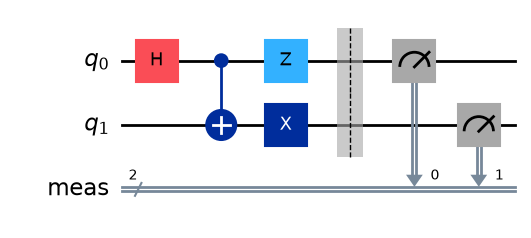

In [2]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

# Measure state
qc.measure_all()

# Draw circuit
qc.draw('mpl')

In [5]:
# Load IBM Quantum Compute Service
from qiskit_ibm_runtime import QiskitRuntimeService

# Load IBM Quantum Compute Service
# IMPORTANT: Replace "YOUR_TOKEN_HERE" with your actual IBM Quantum API token.
# You can find your token on your IBM Quantum account page.
QiskitRuntimeService.save_account(
   channel="ibm_quantum_platform",
   token="6xVaPP7kie54r_bNDB06LL6jbqFiZzFFEA_NRIdDLafy",
   overwrite=True,
   set_as_default=True,
)
service = QiskitRuntimeService(channel="ibm_quantum_platform")


# Or load saved credentials (if uncommenting the above, keep this line commented)
# service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_brisbane")
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-09-21 09:44:45,217: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-21 09:44:45,745: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-21 09:44:49,719: Using instance: open-instance, plan: open


ibm_fez


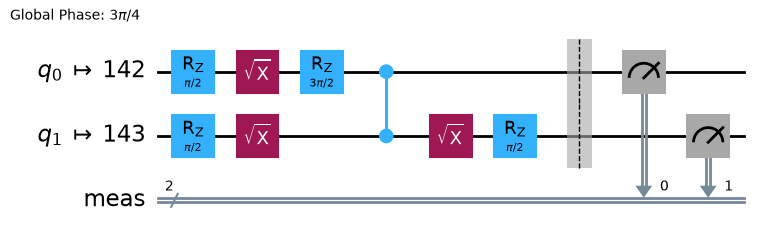

In [6]:
# Transpile the circuit and optimize for running on the quantum computer selected
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

In [7]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

In [8]:
job = sampler.run([qc_isa], shots=100)
# job = sampler_sim.run([qc_isa]) # uncomment if you want to run on a simulator
res = job.result()
counts = res[0].data.meas.get_counts()

counts =  {'10': 58, '01': 41, '00': 1}


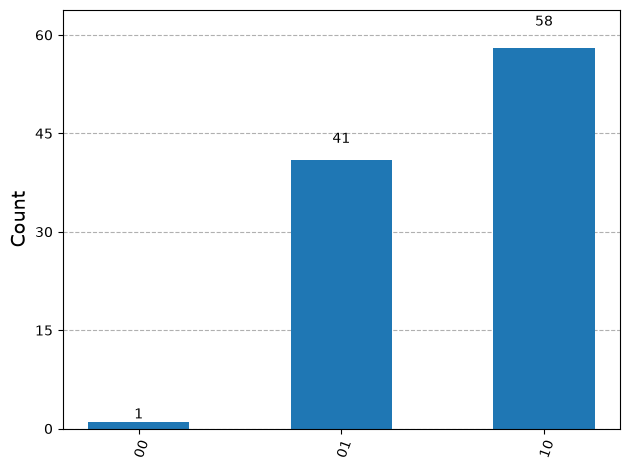

In [9]:
from qiskit.visualization import plot_histogram

print("counts = ", counts)
plot_histogram(counts)

In [14]:
# Import IBM Quantum primitives
from qiskit.quantum_info import SparsePauliOp

# Parameters
J = 1.0  # antiferromagnetic coupling (J>0)
hx = -0.5  # transverse field strength

# 1. Define the Hamiltonian H = J Z1 Z2 + hx (X1 + X2)
obs = SparsePauliOp.from_list([("ZZ", J), ("XI", hx), ("IX", hx)])

# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)


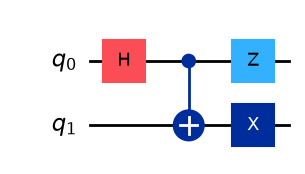

In [15]:
qc.draw('mpl')

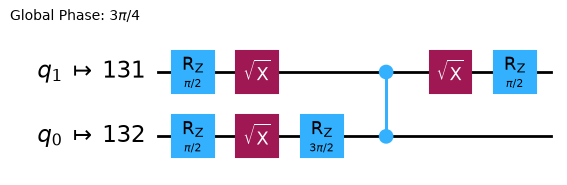

In [16]:
# Transpile the circuit and optimize for running on the quantum computer selected
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

qc_isa.draw("mpl")

In [17]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [18]:
pubs = [(qc_isa, obs_isa)]
job = estimator.run([[qc_isa, obs_isa]])
res = job.result()

# Uncomment lines below to run the job on the Aer simulator with noise model from real backend
# job = estimator_sim.run([[qc_isa,obs_isa]])
# res=job.result()

In [19]:
print(res[0].data.evs)

-0.9953879914745788
